# Clasificación Básica: Predecir una imagen de moda

Esta Guia entrena un modelo de red neuronal para clasificar imágenes de ropa, como tennis y camisetas.

Esta Guia usa [tf.keras](https://www.tensorflow.org/guide/keras), un API de alto nivel para construir y entrenar modelos en Tensorflow.

## Importar el set de datos de moda de MNIST

Esta guia usa el set de datos de [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist)
que contiene mas de 70,000 imágenes en 10 categorias. Las imágenes muestran articulos individuales de ropa a una resolucion baja (28 por 28 pixeles) como se ve aca:

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Fashion-MNIST samples</a> (by Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

Para importar y cargar el set de datos de MNIST directamente de TensorFlow:

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras

In [57]:
dataset = keras.datasets.fashion_mnist
dataset.load_data()

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [58]:
len(dataset.load_data()[0])

2

In [59]:
(X_train, y_train), (X_test, y_test) = dataset.load_data()

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


La *class* de ropa que la imagen representa.

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>T-shirt/top</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Trouser</td>
  </tr>
    <tr>
    <td>2</td>
    <td>Pullover</td>
  </tr>
    <tr>
    <td>3</td>
    <td>Dress</td>
  </tr>
    <tr>
    <td>4</td>
    <td>Coat</td>
  </tr>
    <tr>
    <td>5</td>
    <td>Sandal</td>
  </tr>
    <tr>
    <td>6</td>
    <td>Shirt</td>
  </tr>
    <tr>
    <td>7</td>
    <td>Sneaker</td>
  </tr>
    <tr>
    <td>8</td>
    <td>Bag</td>
  </tr>
    <tr>
    <td>9</td>
    <td>Ankle boot</td>
  </tr>
</table>

Cada imagen es mapeada a una unica etiqueta. Ya que los *Class names* no estan incluidos en el dataset. Los guardamos en la siguiente lista:

In [60]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
len(class_names)

10

In [61]:
y_train

array([9, 0, 0, ..., 3, 0, 5], shape=(60000,), dtype=uint8)

## Explore el set de datos

* ¿Cuántas imágenes hay en train?
* ¿Y en test?
* ¿De cuántos pixels se compone cada imagen?
* ¿Cuáles son los valores de los labels?

In [62]:
print(X_train.shape)
print (X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [ ]:
# X_train tiene 60.000 imágenes
# X_test tiene 10.000 imágenes
# De 28x28 pixels

## Pre-procese el set de datos

Inspecciona y representa la primera imagen del dataset de train. Para ello, utiliza la función `imshow` de matplotlib.

C:\Users\NaiaJon\AppData\Local\Temp\ipykernel_8584\1030106953.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.imshow(X_train[0],cmap=plt.cm.get_cmap('Greys'));


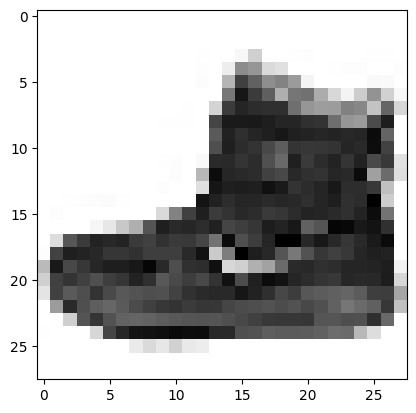

In [63]:
plt.imshow(X_train[0],cmap=plt.cm.get_cmap('Greys'));

Escala los conjuntos de train y test para que vayan del 0 al 1. No hace falta usar ninguna librería. Con realizar una división en cada conjunto será suficiente.

In [64]:
# Lo dividimos entre 255
X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255

In [12]:
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

Para verificar que el set de datos está en el formato adecuado y que están listos para construir y entrenar la red, vamos a desplegar las primeras 25 imágenes del *training set* y despleguemos el nombre de cada clase debajo de cada imagen.

In [65]:
print(type(y_train))
print(len(y_train))

<class 'numpy.ndarray'>
60000


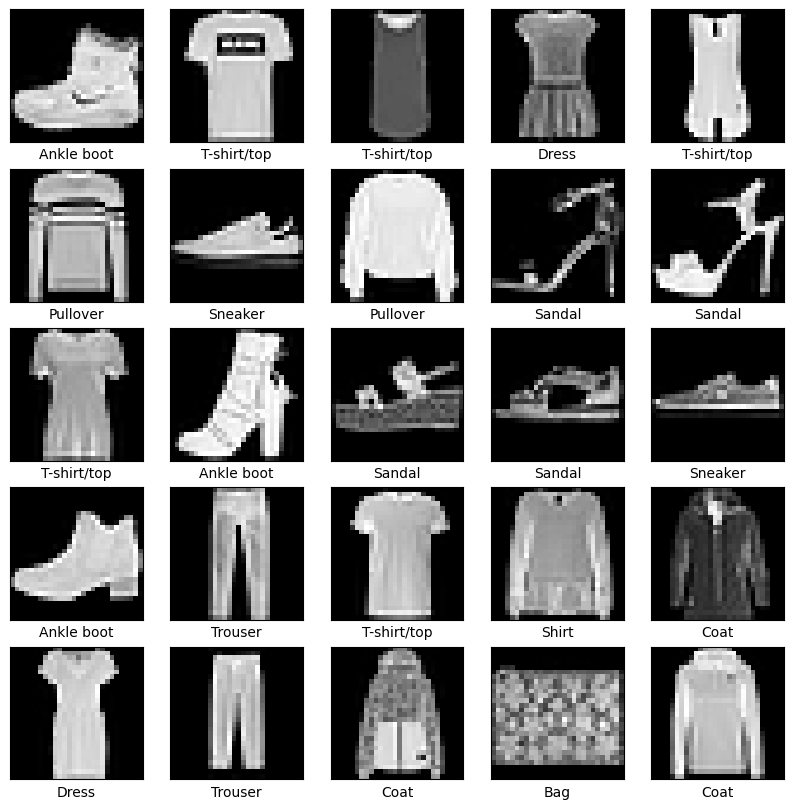

In [66]:
# Las imágenes están en X_train y los label en y_test

import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid (False)
    plt.imshow(X_train[i], cmap='gray')
    label = y_train[i]
    plt.xlabel(str(class_names[label])) # así lo pone arriba  
plt.show()

## Construir el Modelo

Construir la red neuronal requiere configurar las capas del modelo y luego compilar el modelo.

In [67]:
# Separamos una parte para validación

X_val = X_train[-10000:] # coge las últimas 10.000
y_val = y_train[-10000:]

X_train = X_train[:-10000]
y_train = y_train[:-10000]

In [68]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(50000, 28, 28)
(10000, 28, 28)
(10000, 28, 28)


### Configurar las Capas
Construye todas las capas del modelo.

In [69]:
#Es un modelo secuencial: una capa detrás de otra
model = keras.models.Sequential()

# Capa entrada --> la primera capa es de aplanado (ya está definido para que no lo hagamos a mano)
model.add(keras.layers.Flatten(input_shape=(28, 28))) # son todas del mismo tamaño, si no habría que aplicar 
                                                      #técnicas de padding (o no se qué)

# Hidden layer --> los valores que nos da la gana
model.add(keras.layers.Dense(units = 300,
                            activation='relu'))

# Hidden layer --> los valores que nos da la gana
model.add(keras.layers.Dense(units = 100,
                            activation='relu'))

# Capa salida --> definido por el problema: son 10 clases las que quiero diferenciar y al ser una clasificación
# multiclase tiene que ser softmax (lo veremos)
model.add(keras.layers.Dense(units = 10,
                            activation='softmax'))

c:\Users\NaiaJon\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Compila el modelo

Antes de que el modelo este listo para entrenar , se necesitan algunas configuraciones más. Estas son agregadas durante el paso de compilacion del modelo:

* *Loss function* —Esto mide que tan exacto es el modelo durante el entrenamiento. Quiere minimizar esta función para dirigir el modelo en la dirección adecuada.
* *Optimizer* — Esto es cómo el modelo aprende basado en el set de datos que ve y la función de pérdida.
* *Metrics* — Se usan para monitorear los pasos de entrenamiento y de pruebas.


Como es un problema de clasificación multiclase, tendrás que usar `sparse_categorical_crossentropy` como función de coste. En cuanto a las métricas, usa simplemente `accuracy`.

In [70]:
model.compile(
    optimizer = keras.optimizers.SGD(), #Stocastic Gradient Descent
    loss = keras.losses.SparseCategoricalCrossentropy(), # es la función de pérdida a optimizar
    metrics = [keras.metrics.SparseCategoricalAccuracy()] # métrica
)

In [36]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

## Entrenar el Modelo
Empieza entrenándolo con 10 epochs. Prueba con más

In [71]:
history = model.fit(
    X_train,
    y_train,
    batch_size = 128, # tamaño del lote
    epochs = 10,
    validation_data = (X_val, y_val) # validation_split = 0.1
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1177 - sparse_categorical_accuracy: 0.6666 - val_loss: 0.7533 - val_sparse_categorical_accuracy: 0.7531
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6729 - sparse_categorical_accuracy: 0.7779 - val_loss: 0.6163 - val_sparse_categorical_accuracy: 0.7921
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5820 - sparse_categorical_accuracy: 0.8045 - val_loss: 0.5667 - val_sparse_categorical_accuracy: 0.8004
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5344 - sparse_categorical_accuracy: 0.8190 - val_loss: 0.5269 - val_sparse_categorical_accuracy: 0.8159
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5059 - sparse_categorical_accuracy: 0.8261 - val_loss: 0.5055 - val_sparse_categorical_accuracy: 0.8191
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4856 - sparse_categorical_accuracy: 0.8337 - val_loss: 0.4953 - val_sparse_categorical_accuracy: 0.8215
Epoc

In [72]:
# Con 10 llega a un 85% de accuracy. Incrementamos
history = model.fit(
    X_train,
    y_train,
    batch_size = 128, # tamaño del lote
    epochs = 50,
    validation_data = (X_val, y_val) # validation_split = 0.1
)


Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4306 - sparse_categorical_accuracy: 0.8492 - val_loss: 0.4411 - val_sparse_categorical_accuracy: 0.8419
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4232 - sparse_categorical_accuracy: 0.8538 - val_loss: 0.4381 - val_sparse_categorical_accuracy: 0.8443
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4171 - sparse_categorical_accuracy: 0.8541 - val_loss: 0.4336 - val_sparse_categorical_accuracy: 0.8478
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4112 - sparse_categorical_accuracy: 0.8573 - val_loss: 0.4511 - val_sparse_categorical_accuracy: 0.8379
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4061 - sparse_categorical_accuracy: 0.8592 - val_loss: 0.4212 - val_sparse_categorical_accuracy: 0.8527
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4005 - sparse_categorical_accuracy: 0.8610 - val_loss: 0.4220 - val_sparse_categorical_accuracy: 0.8484
Epoc

In [ ]:
# Sigue mejorando con 50... pero entiendo que si sigues muchos epochs más se corre el riesgo de overfitting

## Evaluar Accuracy
Prueba el rendimiento del modelo con los datos de test

In [73]:
predicciones = model.evaluate (X_test, y_test)
predicciones

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3636 - sparse_categorical_accuracy: 0.8729


[0.3635740578174591, 0.8729000091552734]

## Hacer predicciones

Con el modelo entrenado puedes usarlo para hacer predicciones sobre imagenes.

El modelo ha predicho la etiqueta para cada imagen en el set de datos de *test* (prueba). Miremos la primera prediccion:

In [75]:
prediccion1 = model.predict(X_test[:1])
print(prediccion1.shape)
prediccion1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
(1, 10)


array([[3.45076660e-05, 6.03212072e-07, 1.15749235e-05, 1.78845785e-05,
        6.62735829e-07, 4.39187363e-02, 1.80216928e-04, 2.71618050e-02,
        1.16745394e-03, 9.27506685e-01]], dtype=float32)

*Una* prediccion es un array de 10 numeros. Estos representan el nivel de "confianza" del modelo sobre las imagenes de cada uno de los 10 articulos de moda/ropa. Puedes revisar cual tiene el nivel mas alto de confianza:

In [76]:
def plot_image(i, predictions_array, true_label, img):
  predictions_array, true_label, img = predictions_array, true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  predictions_array, true_label = predictions_array, true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

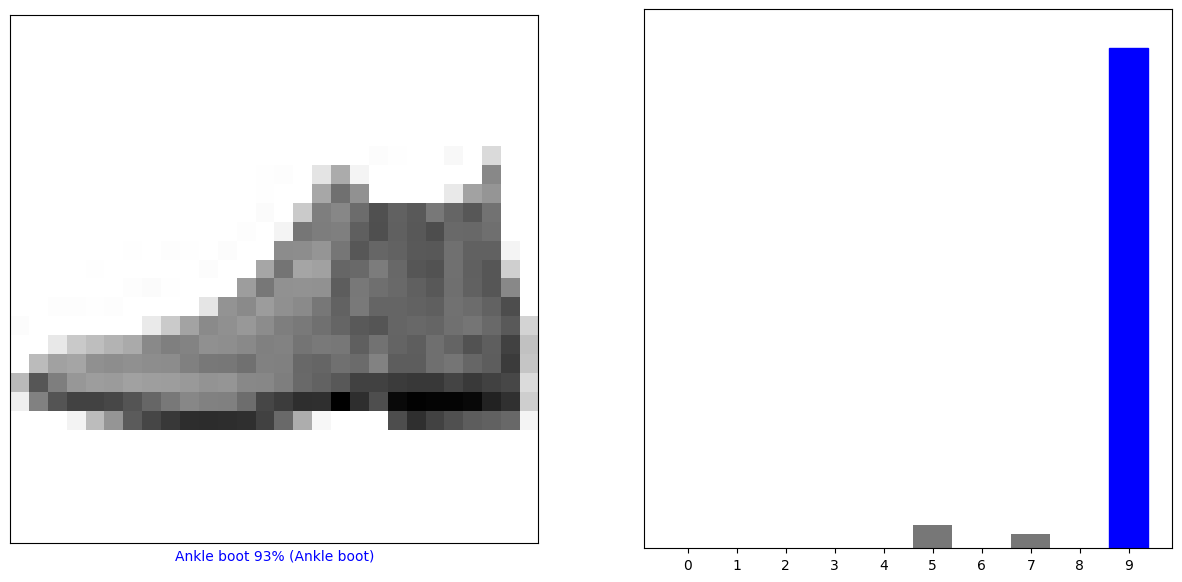

In [77]:
i = 0
plt.figure(figsize=(15,7))
plt.subplot(1,2,1)
plot_image(i, prediccion1[i], y_test, X_test)
plt.subplot(1,2,2)
plot_value_array(i, prediccion1[i], y_test)

Entonces, el modelo tiene mayor confianza que esta imagen es un bota de tobillo "ankle boot" o `class_names[9]`. Examinando las etiquetas de *test* o de pruebas muestra que esta clasificación es correcta:

**Grafica** esto para poder ver todo el set de la prediccion de las 10 clases.

Miremos la imagen [0], sus predicciones y el array de predicciones. Las etiquetas de predicción correctas estan en azul y las incorrectas están en rojo. El número entrega el porcentaje (sobre 100) para la etiqueta predicha.

Vamos a graficar multiples imagenes con sus predicciones. Notese que el modelo puede estar equivocado aun cuando tiene mucha confianza.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
(10, 10)


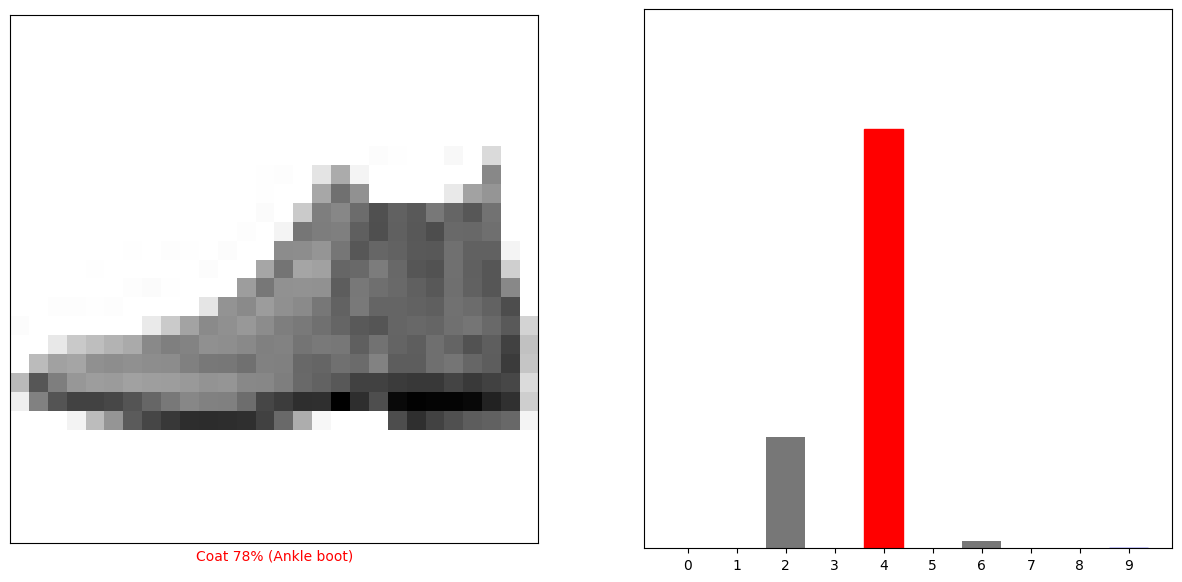

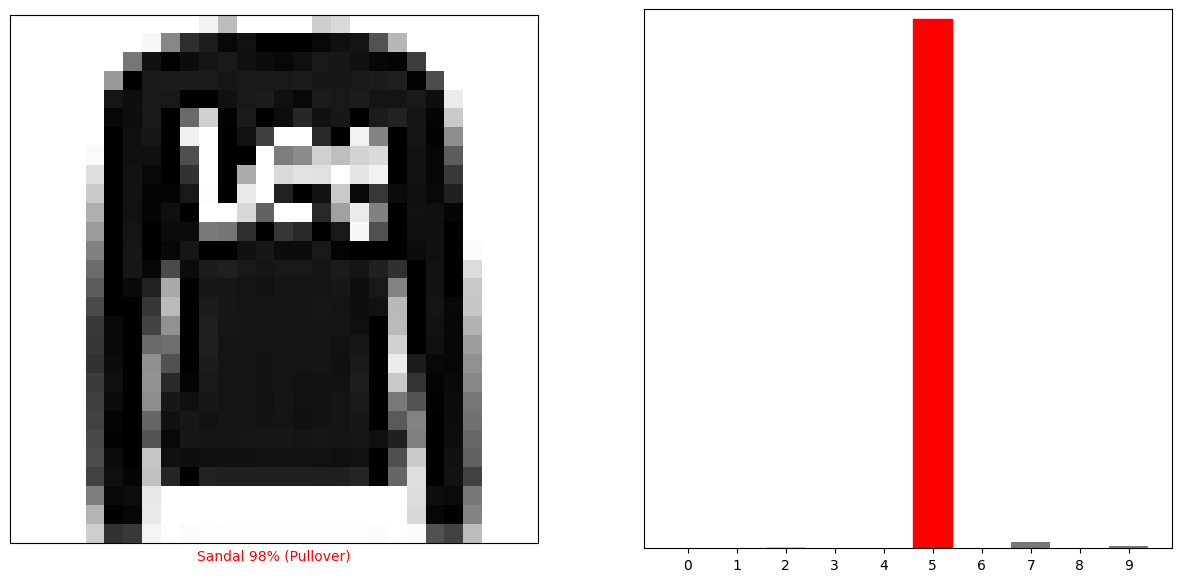

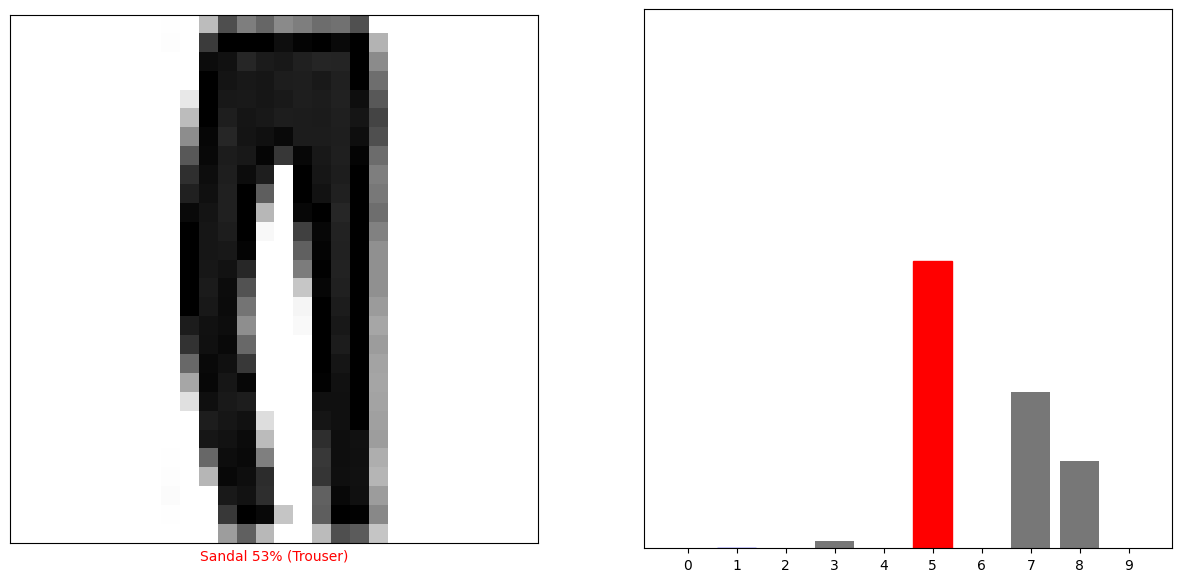

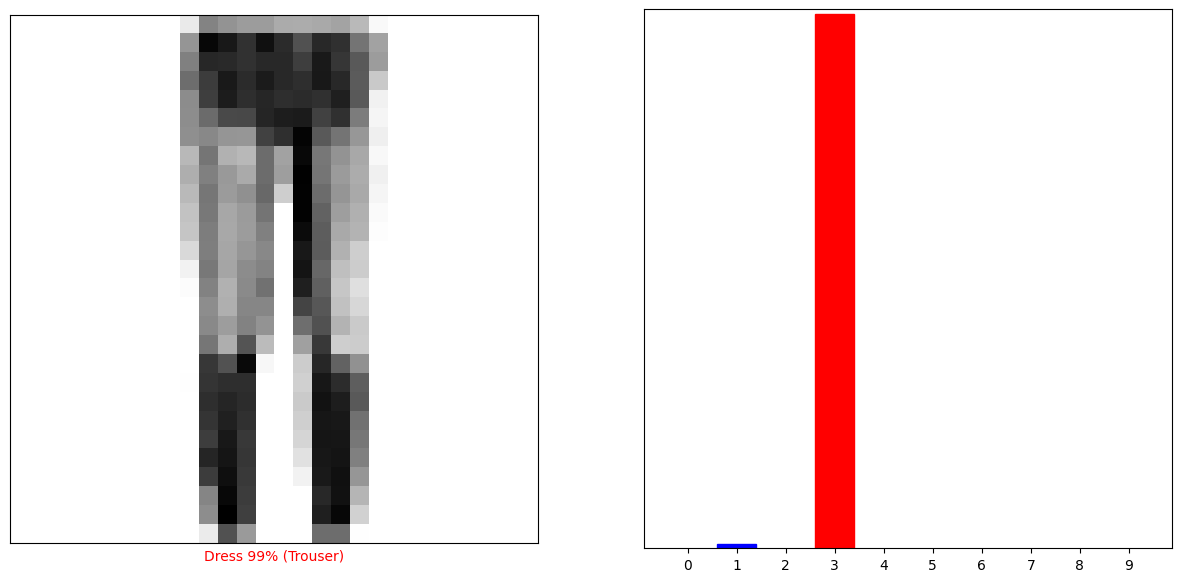

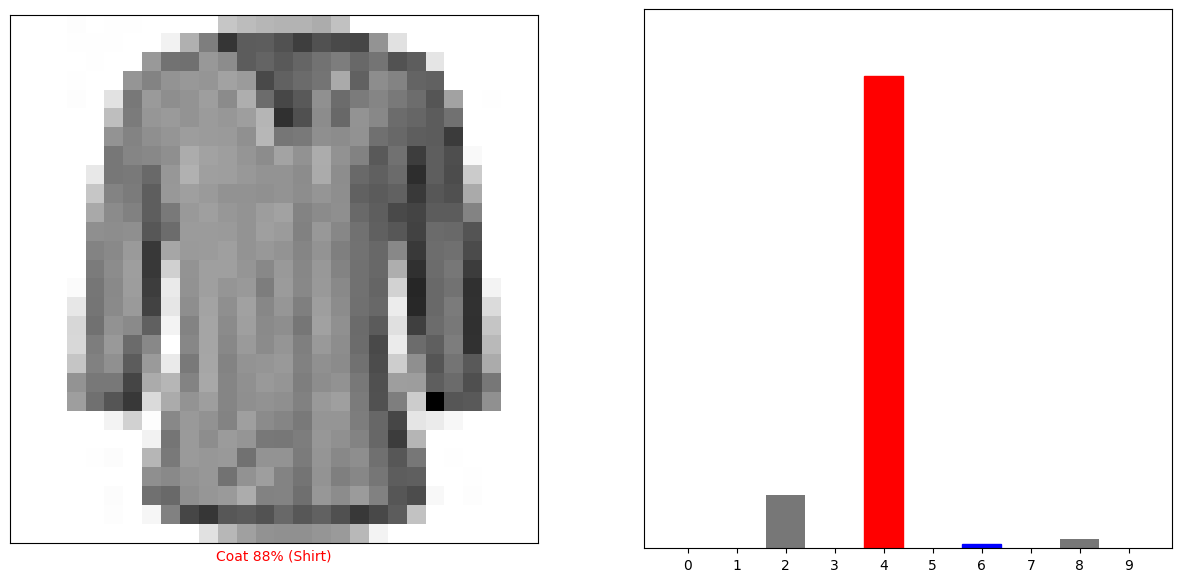

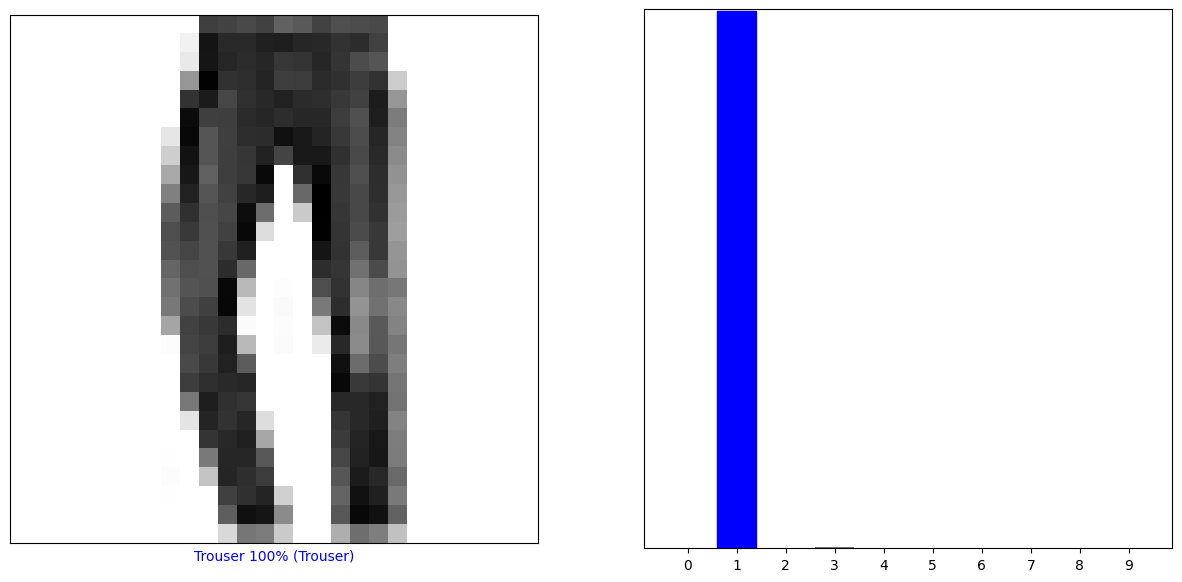

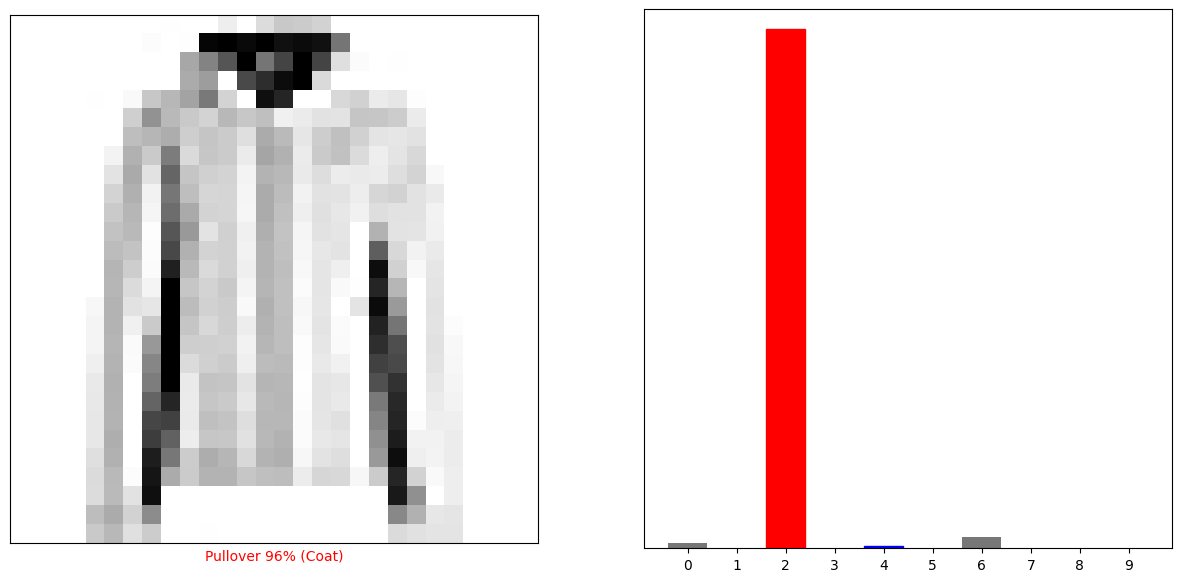

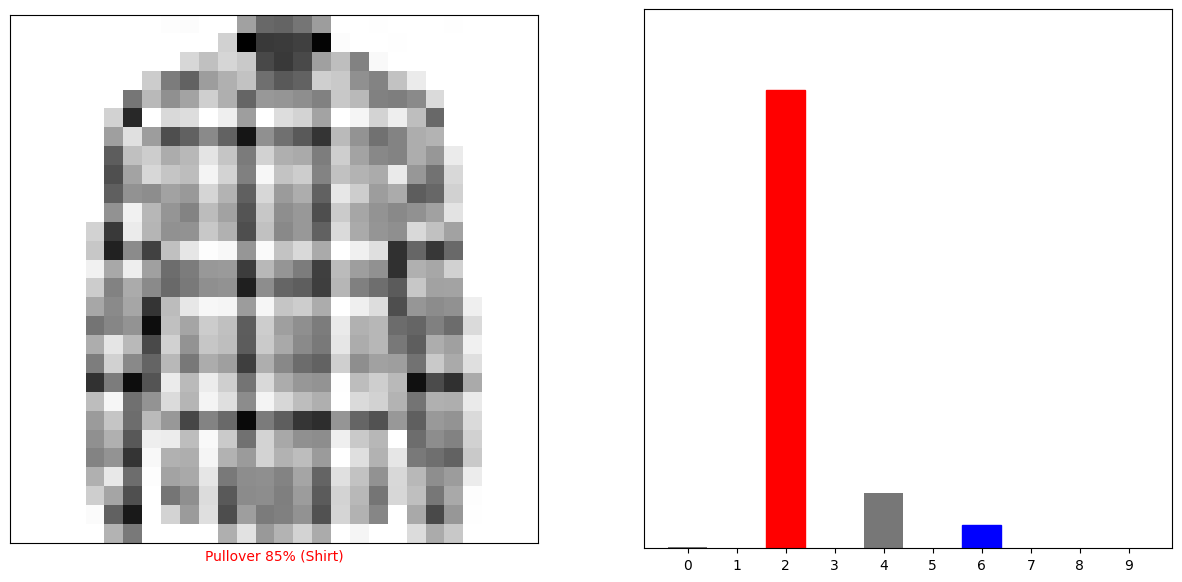

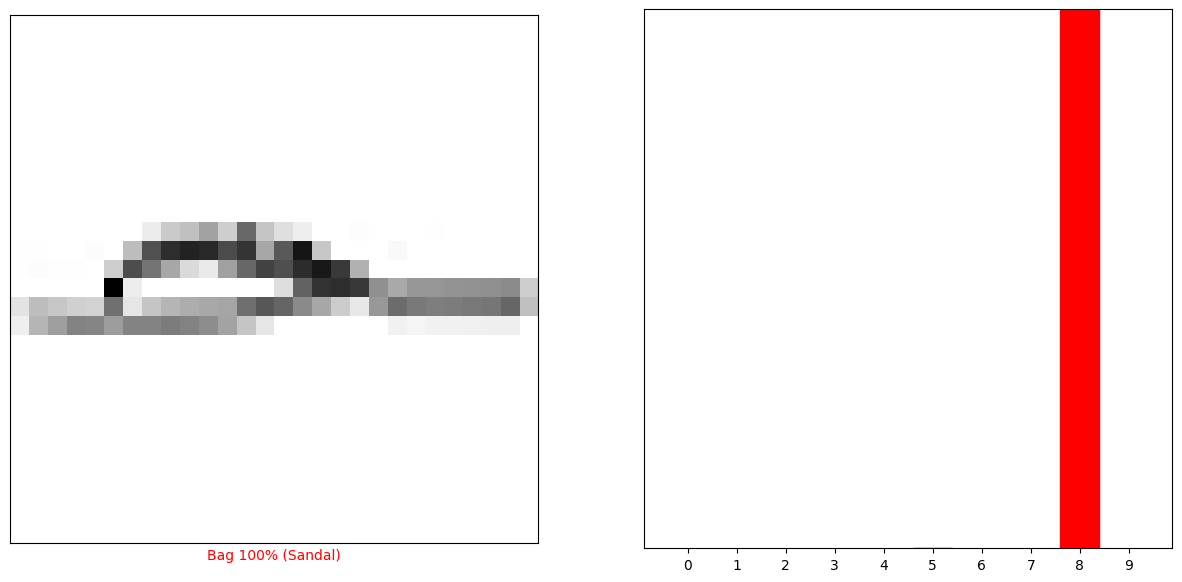

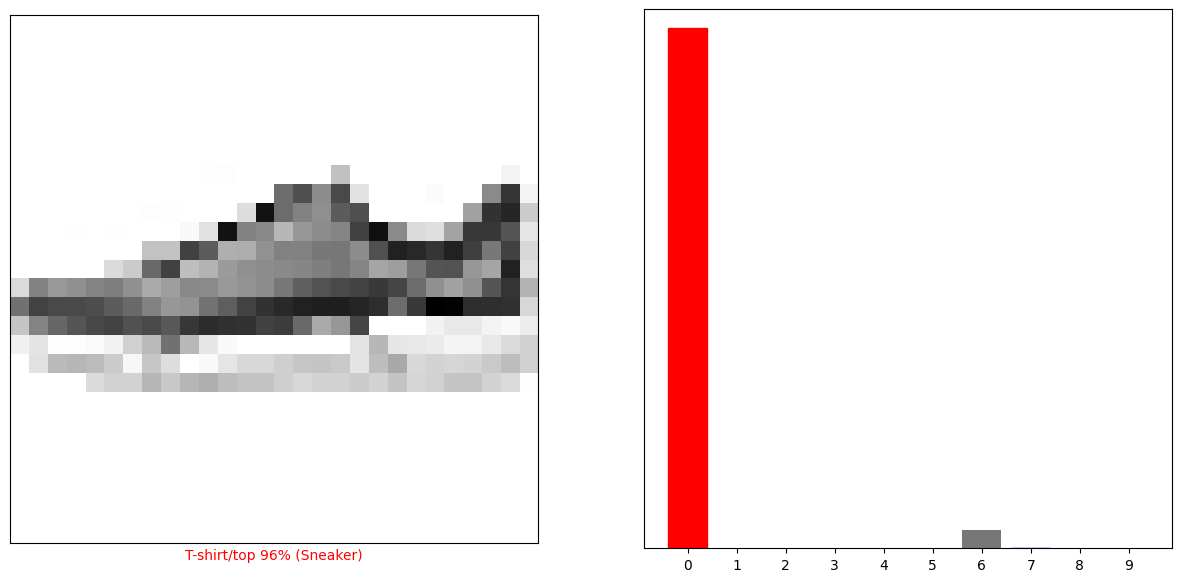

In [78]:
predictions10 = model.predict(X_test[10:20])
print(predictions10.shape)
i = 0
for i in range(len(predictions10)):
    plt.figure(figsize=(15,7))
    plt.subplot(1,2,1)
    plot_image(i, predictions10[i], y_test, X_test)
    plt.subplot(1,2,2)
    plot_value_array(i, predictions10[i], y_test)

In [ ]:
# Falla más que una escopeta de feria :-)

Evalúa tu modelo con una matriz de confusión e interprétala.

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, model.predict(X_test).argmax(axis=1))
# Fila: valor real
# Columna: prediccion
# Falla mucho en 0, en 3, en 4, muchísimo en 6


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 808us/step


array([[841,   1,  19,  35,   7,   1,  80,   0,  16,   0],
       [  4, 968,   1,  22,   2,   0,   1,   0,   2,   0],
       [ 15,   3, 829,  12,  95,   0,  39,   0,   6,   1],
       [ 31,  15,  18, 865,  45,   0,  20,   0,   6,   0],
       [  0,   1, 113,  20, 828,   0,  33,   0,   5,   0],
       [  0,   0,   0,   1,   0, 948,   0,  33,   2,  16],
       [129,   1, 144,  28,  94,   0, 585,   0,  19,   0],
       [  0,   0,   0,   0,   0,  23,   0, 939,   0,  38],
       [  3,   1,   6,   7,   6,   2,   8,   5, 962,   0],
       [  1,   0,   0,   0,   0,   5,   0,  30,   0, 964]])

Finalmente, usamos el modelo entrenado para hacer una prediccion sobre una única imagen.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
(1, 10)


C:\Users\NaiaJon\AppData\Local\Temp\ipykernel_8584\423393250.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.imshow(X_test[1034],cmap=plt.cm.get_cmap('Greys'));


array([[6.9817214e-04, 5.1433653e-02, 2.6815684e-04, 9.4693047e-01,
        6.2369398e-04, 1.4551673e-09, 3.8242557e-05, 1.4018399e-07,
        7.5631815e-06, 2.5274071e-08]], dtype=float32)

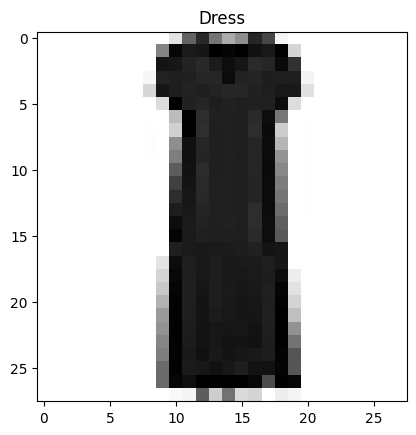

In [ ]:
plt.imshow(X_test[1034],cmap=plt.cm.get_cmap('Greys'));
label = y_test[1034]
plt.title (class_names[label]) # Que me la muestre y me imprima su clase
#El modelo espera (n_muestras, 28, 28, 3)  # batch_size + dimensiones
# Si quiero predecir el 1034
prediccion = model.predict(X_test[1034:1035])
print(prediccion.shape)
prediccion
#Clase más probable, la 3 --> dress. Acierta! Milagro :-)